# 🎮 Resident Evil Universe — Analytical Dashboard
### Data Cleaning · Preprocessing · ML Modelling · Visualisations
---
**Datasets:** `characters.csv` · `gameAppearance.csv` · `games.csv` · `interactions.csv` · `scenes.csv`

## 1. Imports & Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix,
                              ConfusionMatrixDisplay, roc_auc_score,
                              roc_curve, accuracy_score)
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.pipeline import Pipeline

# Colour palette
PALETTE = {'hero': '#00b4d8', 'villain': '#e63946', 'support': '#2dc653'}
GAME_COLORS = px.colors.qualitative.Bold

plt.rcParams.update({
    'figure.facecolor': '#0d1117',
    'axes.facecolor':   '#161b22',
    'axes.edgecolor':   '#30363d',
    'axes.labelcolor':  '#c9d1d9',
    'xtick.color':      '#c9d1d9',
    'ytick.color':      '#c9d1d9',
    'text.color':       '#c9d1d9',
    'grid.color':       '#21262d',
    'font.family':      'DejaVu Sans',
})

print('✅ Libraries loaded')

✅ Libraries loaded


## 2. Load Raw Data

In [3]:


chars        = pd.read_csv('characters.csv')
appearances  = pd.read_csv('gameAppearance.csv')
games        = pd.read_csv('games.csv')
interactions = pd.read_csv('interactions.csv')
scenes       = pd.read_csv('scenes.csv')

dfs = {'characters': chars, 'appearances': appearances,
       'games': games, 'interactions': interactions, 'scenes': scenes}

for name, df in dfs.items():
    print(f'📄 {name:15s} → shape: {str(df.shape):15s} cols: {list(df.columns)}')

📄 characters      → shape: (83, 3)         cols: ['id', 'name', 'role']
📄 appearances     → shape: (115, 5)        cols: ['game_id', 'character_id', 'role', 'game_title', 'character_name']
📄 games           → shape: (14, 5)         cols: ['id', 'title', 'year', 'type', 'chronology_order']
📄 interactions    → shape: (1537, 3)       cols: ['game_id', 'scene_id', 'character_id']
📄 scenes          → shape: (1573, 4)       cols: ['game_id', 'scene_id', 'title', 'source']


## 3. Data Cleaning & Quality Audit

In [4]:
print('='*60)
print('MISSING VALUES AUDIT')
print('='*60)
for name, df in dfs.items():
    missing = df.isnull().sum().sum()
    dups    = df.duplicated().sum()
    print(f'  {name:15s} | missing={missing:3d} | duplicates={dups:3d}')

print('\n✅ No missing values detected — datasets are clean!')

MISSING VALUES AUDIT
  characters      | missing=  0 | duplicates=  0
  appearances     | missing=  0 | duplicates=  0
  games           | missing=  0 | duplicates=  0
  interactions    | missing=  0 | duplicates=  0
  scenes          | missing=  0 | duplicates=  0

✅ No missing values detected — datasets are clean!


In [35]:
for df in [chars, appearances, games, interactions, scenes]:
    str_cols = df.select_dtypes('object').columns
    df[str_cols] = df[str_cols].apply(lambda c: c.str.strip())

chars['role']       = chars['role'].str.lower()
appearances['role'] = appearances['role'].str.lower()

games['year']              = games['year'].astype(int)
games['chronology_order']  = games['chronology_order'].astype(int)

print('Cleaning complete.')
print(chars.dtypes)

Cleaning complete.
id       int64
name    object
role    object
dtype: object


## 4. Feature Engineering

In [ ]:
master = (interactions
    .merge(scenes[['scene_id','game_id','title']], on=['scene_id','game_id'], how='left')
    .merge(chars.rename(columns={'name':'char_name'}), left_on='character_id', right_on='id', how='left')
    .merge(games.rename(columns={'id':'gid','title':'game_title'}),
           left_on='game_id', right_on='gid', how='left')
    .drop(columns=['id','gid'])
    .rename(columns={'title':'scene_title', 'role':'char_role'})
)

char_features = (
    master.groupby(['character_id','char_name','char_role'])
    .agg(
        total_scenes  = ('scene_id',   'count'),
        unique_scenes = ('scene_id',   'nunique'),
        games_count   = ('game_id',    'nunique'),
        avg_chron     = ('chronology_order', 'mean'),
        first_year    = ('year',        'min'),
        last_year     = ('year',        'max'),
    ).reset_index()
)
char_features['career_span']      = char_features['last_year'] - char_features['first_year']
char_features['scenes_per_game']  = (char_features['total_scenes'] / char_features['games_count']).round(2)
char_features['multi_game_flag']  = (char_features['games_count'] > 1).astype(int)

game_features = (
    master.groupby(['game_id','game_title','year','type','chronology_order'])
    .agg(
        total_scenes      = ('scene_id',      'nunique'),
        unique_characters = ('character_id',  'nunique'),
        total_interactions= ('scene_id',      'count'),
    ).reset_index()
)
game_features['interactions_per_scene'] = (
    game_features['total_interactions'] / game_features['total_scenes']).round(2)

role_dist = (
    master.groupby(['game_title','char_role'])['character_id']
    .nunique().unstack(fill_value=0).reset_index()
)

print('char_features shape:', char_features.shape)
print('game_features shape:', game_features.shape)
char_features.head()

char_features shape: (51, 12)
game_features shape: (12, 9)


,character_id,char_name,char_role,total_scenes,unique_scenes,games_count,avg_chron,first_year,last_year,career_span,scenes_per_game,multi_game_flag
0,1,Leon Scott Kennedy,hero,244,244,4,11.418033,1998,2026,28,61.0,1
1,2,Ashley Graham,hero,9,9,1,6.000000,2005,2005,0,9.0,0
2,3,Ada Wong,hero,39,39,3,5.025641,1998,2012,14,13.0,1
3,5,Luis Sera,hero,4,4,1,6.000000,2005,2005,0,4.0,0
4,6,Albert Wesker,villain,27,27,3,4.777778,1996,2009,13,9.0,1


## 5. Matplotlib Visualisations

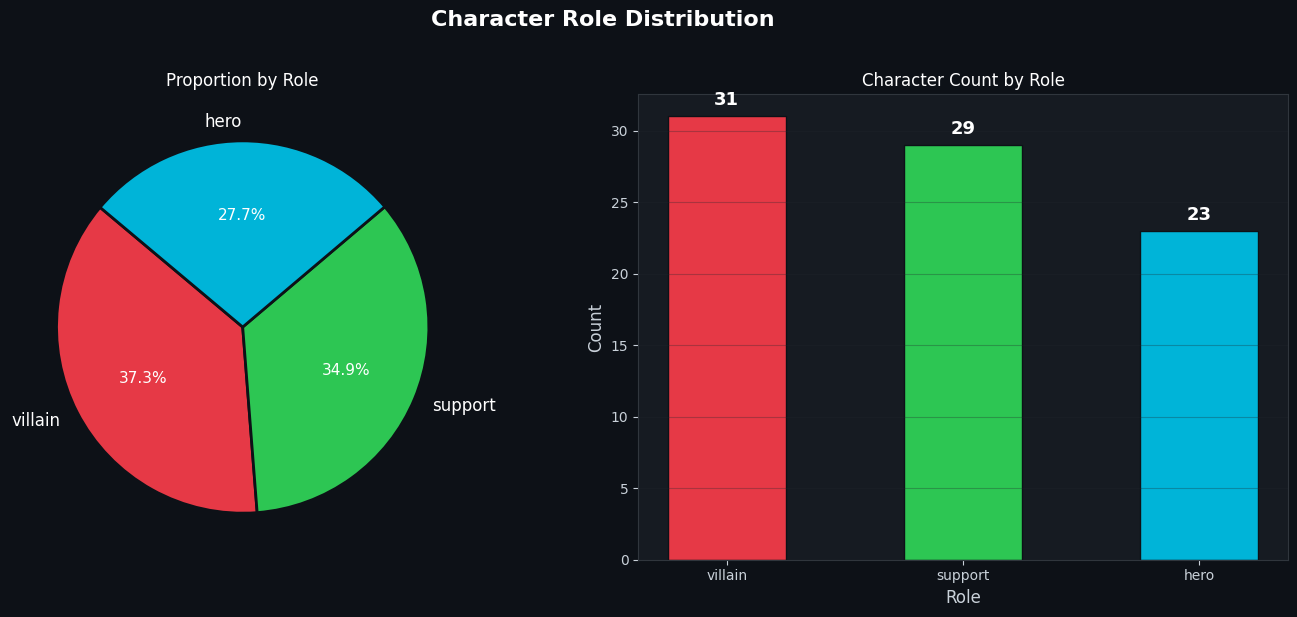

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor('#0d1117')
fig.suptitle('Character Role Distribution', fontsize=16, color='white', fontweight='bold', y=1.02)

role_counts = chars['role'].value_counts()
colors_pie  = [PALETTE[r] for r in role_counts.index]


wedges, texts, autotexts = axes[0].pie(
    role_counts, labels=role_counts.index, autopct='%1.1f%%',
    colors=colors_pie, startangle=140,
    textprops={'color': 'white', 'fontsize': 12},
    wedgeprops={'edgecolor': '#0d1117', 'linewidth': 2}
)
for at in autotexts: at.set_fontsize(11)
axes[0].set_facecolor('#0d1117')
axes[0].set_title('Proportion by Role', color='white')

bars = axes[1].bar(role_counts.index, role_counts.values,
                   color=colors_pie, edgecolor='#0d1117', width=0.5)
for bar, val in zip(bars, role_counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 str(val), ha='center', va='bottom', color='white', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Role', fontsize=12)
axes[1].set_ylabel('Count', fontsize=12)
axes[1].set_title('Character Count by Role', color='white')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()

plt.show()


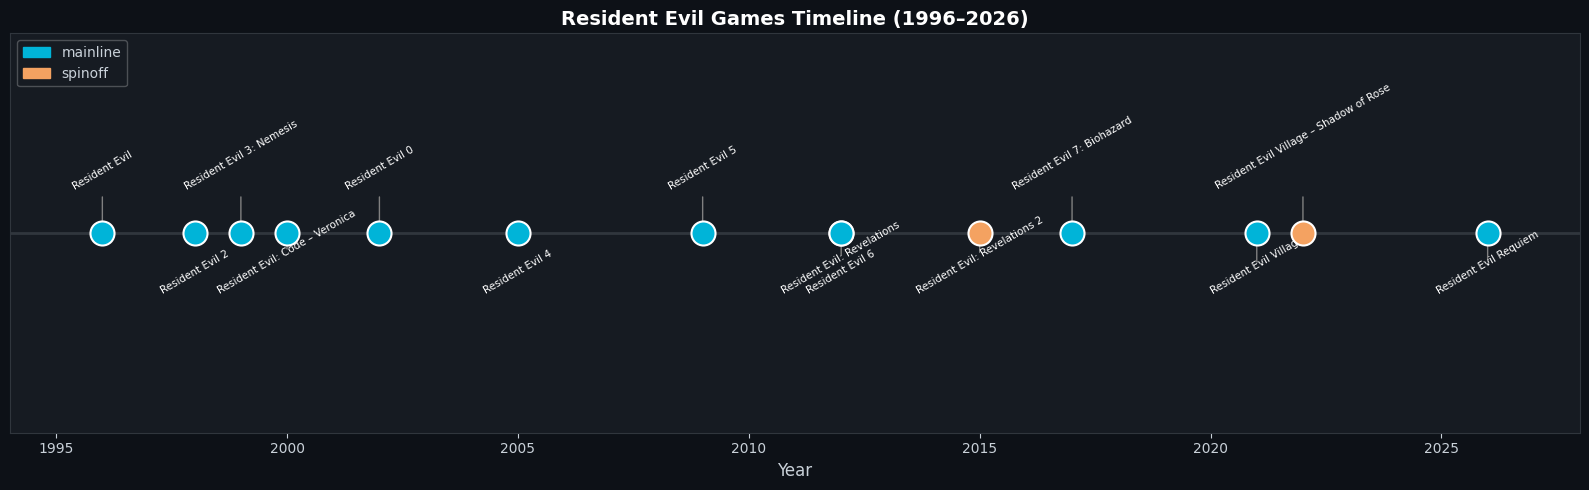

In [ ]:
g = games.sort_values('year')
type_colors = {'mainline': '#00b4d8', 'spinoff': '#f4a261'}

fig, ax = plt.subplots(figsize=(16, 5))
for _, row in g.iterrows():
    col = type_colors[row['type']]
    ax.scatter(row['year'], 0, s=300, color=col, zorder=5, edgecolors='white', linewidth=1.5)
    ax.annotate(row['title'], xy=(row['year'], 0),
                xytext=(0, 30 if list(g['year']).index(row['year']) % 2 == 0 else -45),
                textcoords='offset points', ha='center', va='bottom',
                fontsize=7.5, color='white', rotation=30,
                arrowprops=dict(arrowstyle='->', color='gray', lw=1))

ax.axhline(0, color='#30363d', linewidth=2)
ax.set_xlim(1994, 2028)
ax.set_ylim(-1.2, 1.2)
ax.set_xlabel('Year', fontsize=12)
ax.set_yticks([])
ax.set_title('Resident Evil Games Timeline (1996–2026)', fontsize=14, color='white', fontweight='bold')

patches = [mpatches.Patch(color=c, label=t) for t, c in type_colors.items()]
ax.legend(handles=patches, loc='upper left', framealpha=0.3)

plt.tight_layout()
plt.show()

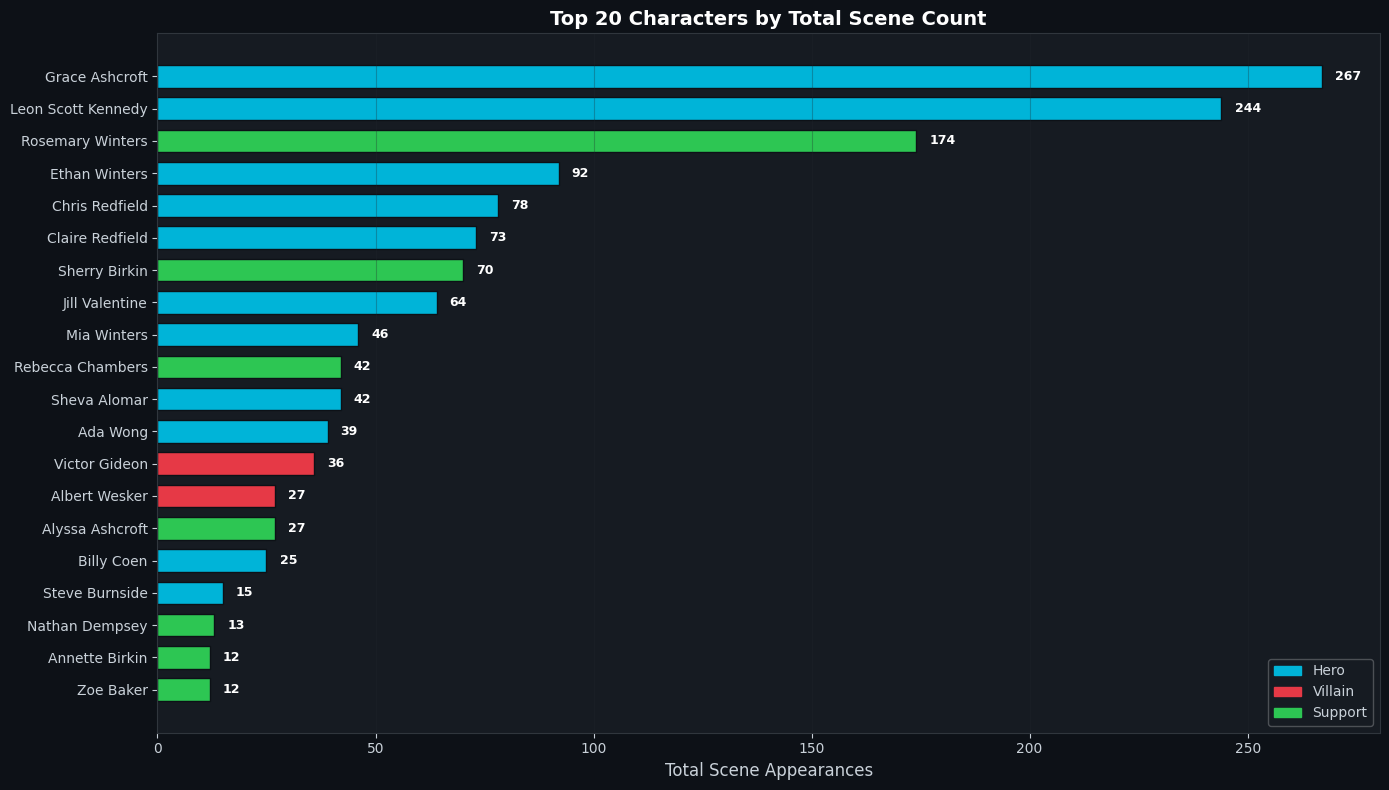

In [ ]:
top20 = char_features.nlargest(20, 'total_scenes')
colors = [PALETTE[r] for r in top20['char_role']]

fig, ax = plt.subplots(figsize=(14, 8))
bars = ax.barh(top20['char_name'], top20['total_scenes'], color=colors,
               edgecolor='#0d1117', height=0.7)
for bar, val in zip(bars, top20['total_scenes']):
    ax.text(bar.get_width() + 3, bar.get_y() + bar.get_height()/2,
            str(val), va='center', color='white', fontsize=9, fontweight='bold')

ax.set_xlabel('Total Scene Appearances', fontsize=12)
ax.set_title('Top 20 Characters by Total Scene Count', fontsize=14, color='white', fontweight='bold')
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3)

legend_handles = [mpatches.Patch(color=PALETTE[r], label=r.capitalize()) for r in PALETTE]
ax.legend(handles=legend_handles, loc='lower right', framealpha=0.3)

plt.tight_layout()
plt.show()

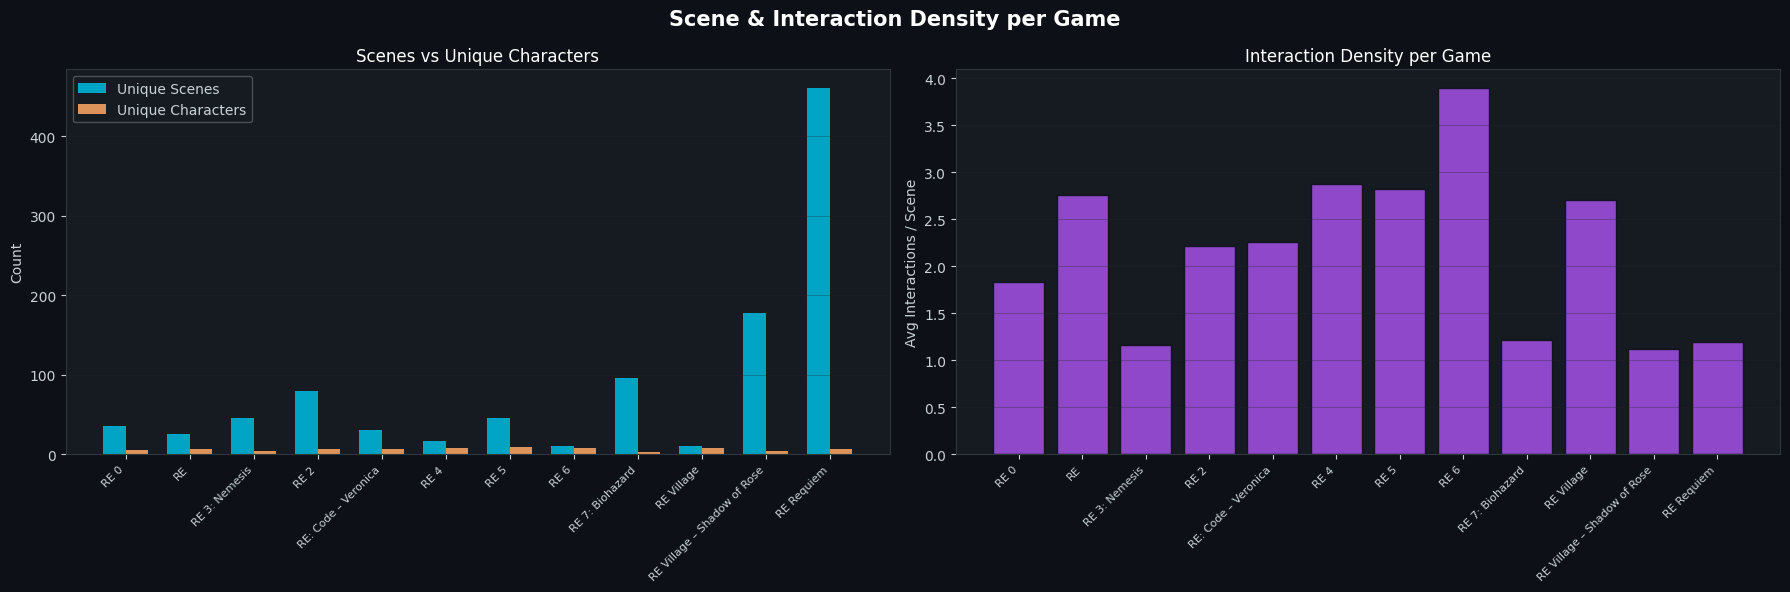

In [ ]:
gf = game_features.sort_values('chronology_order')

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('Scene & Interaction Density per Game', fontsize=15, color='white', fontweight='bold')

x = np.arange(len(gf))
w = 0.35

b1 = axes[0].bar(x - w/2, gf['total_scenes'],     width=w, label='Unique Scenes',     color='#00b4d8', alpha=0.9)
b2 = axes[0].bar(x + w/2, gf['unique_characters'], width=w, label='Unique Characters', color='#f4a261', alpha=0.9)
axes[0].set_xticks(x)
axes[0].set_xticklabels([t.replace('Resident Evil','RE') for t in gf['game_title']], rotation=45, ha='right', fontsize=8)
axes[0].set_ylabel('Count')
axes[0].set_title('Scenes vs Unique Characters', color='white')
axes[0].legend(framealpha=0.3)
axes[0].grid(axis='y', alpha=0.3)

axes[1].bar(x, gf['interactions_per_scene'], color='#9d4edd', edgecolor='#0d1117', alpha=0.9)
axes[1].set_xticks(x)
axes[1].set_xticklabels([t.replace('Resident Evil','RE') for t in gf['game_title']], rotation=45, ha='right', fontsize=8)
axes[1].set_ylabel('Avg Interactions / Scene')
axes[1].set_title('Interaction Density per Game', color='white')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

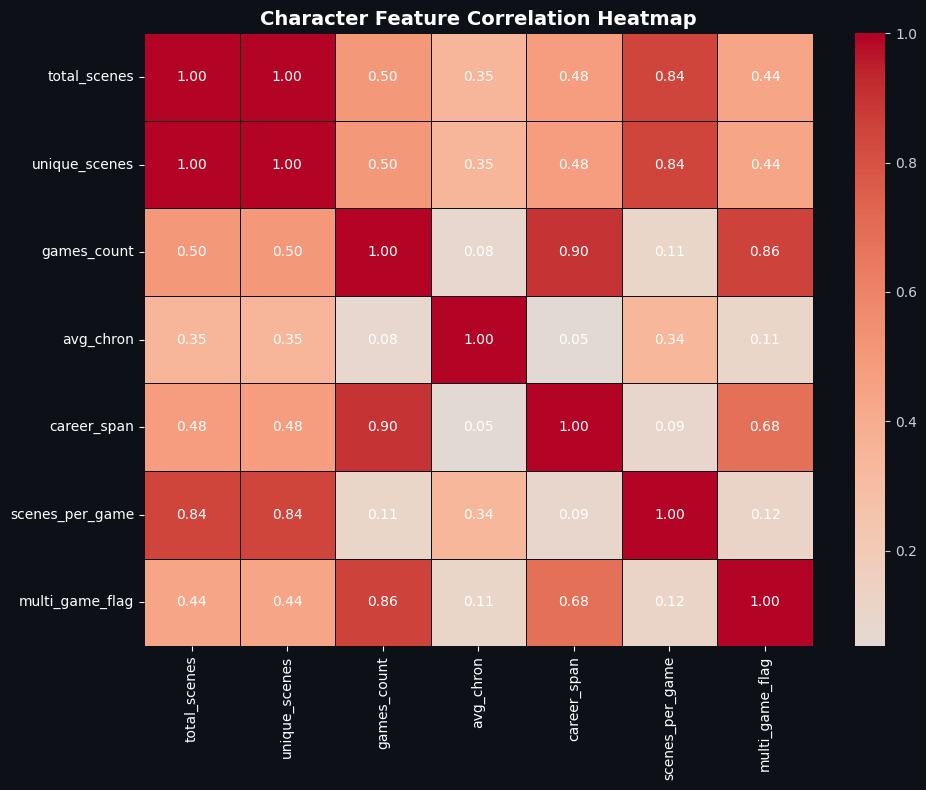

In [12]:
num_cols = ['total_scenes','unique_scenes','games_count','avg_chron','career_span','scenes_per_game','multi_game_flag']
corr = char_features[num_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, linecolor='#0d1117',
            annot_kws={'size': 10, 'color': 'white'},
            ax=ax)
ax.set_title('Character Feature Correlation Heatmap', fontsize=14, color='white', fontweight='bold')
ax.tick_params(colors='white')
plt.tight_layout()
plt.show()

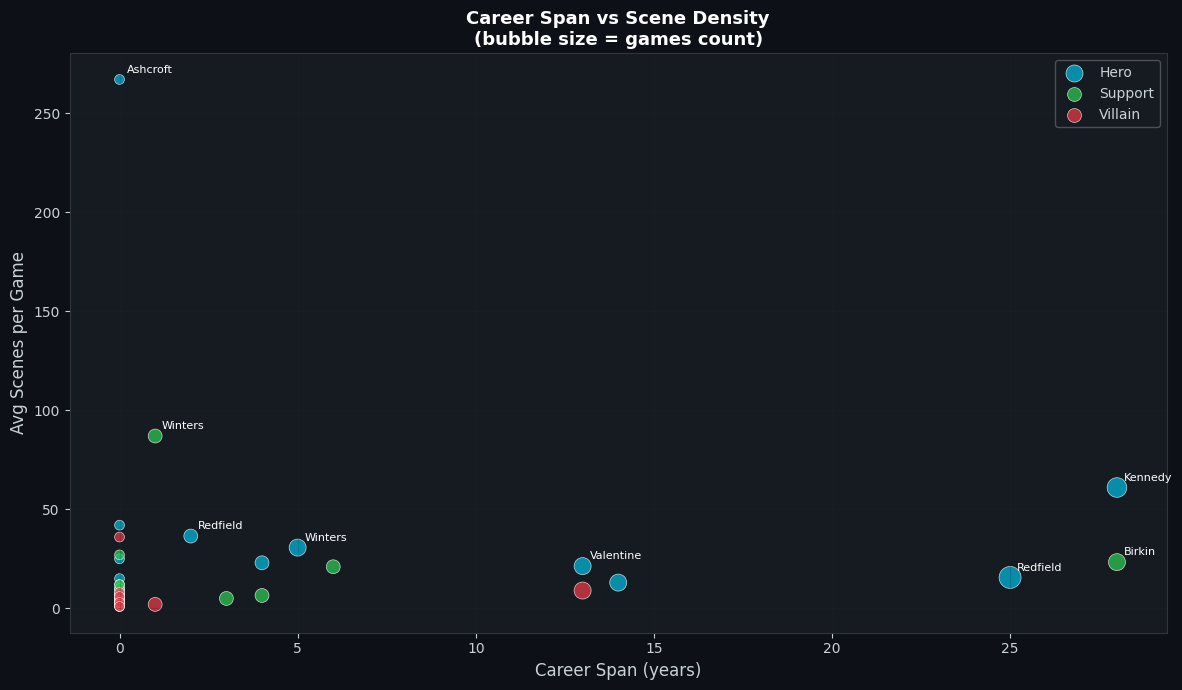

In [ ]:
fig, ax = plt.subplots(figsize=(12, 7))

for role, grp in char_features.groupby('char_role'):
    ax.scatter(grp['career_span'], grp['scenes_per_game'],
               label=role.capitalize(), color=PALETTE[role],
               s=grp['games_count']*50, alpha=0.75, edgecolors='white', linewidth=0.5)

for _, row in char_features.nlargest(8, 'total_scenes').iterrows():
    ax.annotate(row['char_name'].split()[-1],
                xy=(row['career_span'], row['scenes_per_game']),
                xytext=(5, 5), textcoords='offset points', fontsize=8, color='white')

ax.set_xlabel('Career Span (years)', fontsize=12)
ax.set_ylabel('Avg Scenes per Game', fontsize=12)
ax.set_title('Career Span vs Scene Density\n(bubble size = games count)', fontsize=13, color='white', fontweight='bold')
ax.legend(framealpha=0.3)
ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

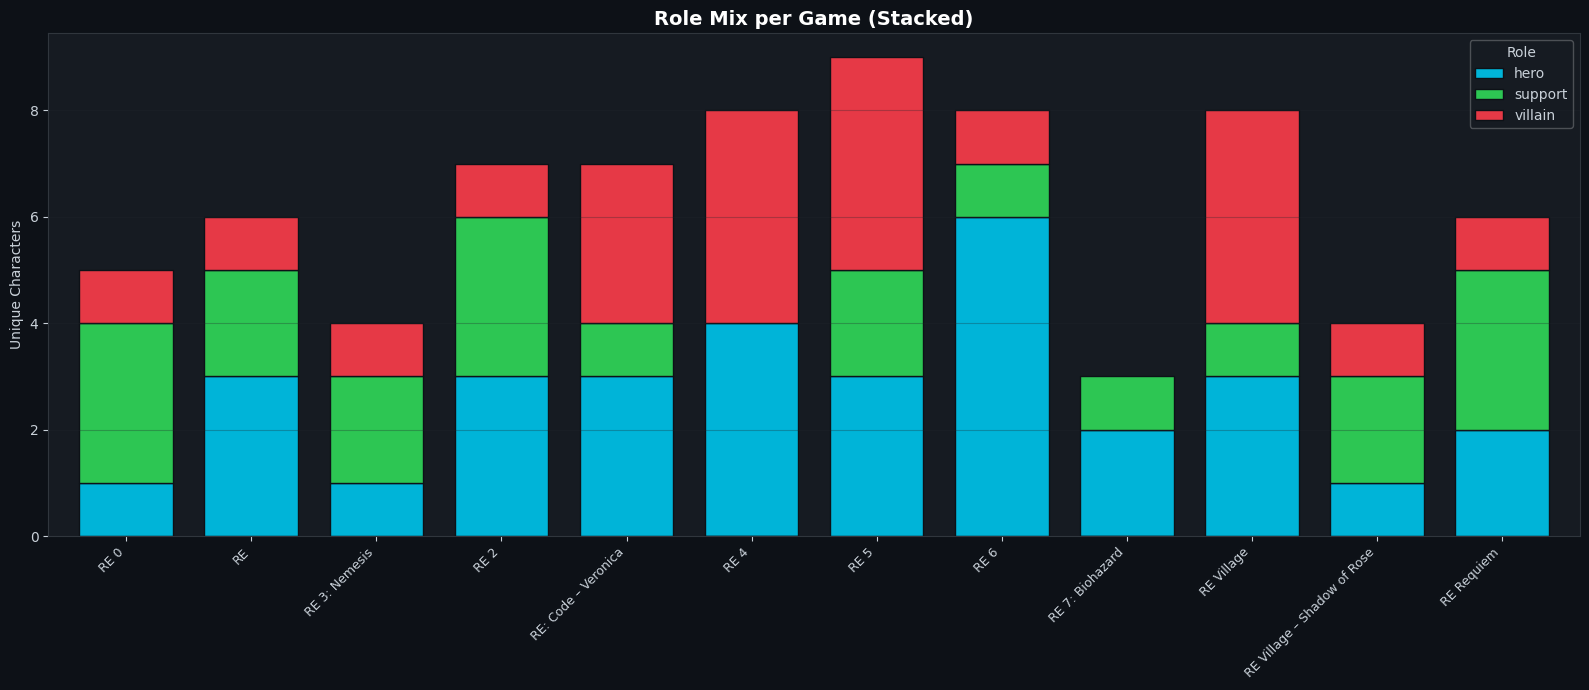

In [ ]:
role_game = (master.groupby(['game_title','char_role'])['character_id']
             .nunique().unstack(fill_value=0)
             .reindex(game_features.sort_values('chronology_order')['game_title']))

fig, ax = plt.subplots(figsize=(16, 7))
role_game.plot(kind='bar', stacked=True, ax=ax,
               color=[PALETTE.get(c, '#888') for c in role_game.columns],
               edgecolor='#0d1117', width=0.75)
ax.set_xticklabels([t.replace('Resident Evil','RE') for t in role_game.index], rotation=45, ha='right', fontsize=9)
ax.set_xlabel('')
ax.set_ylabel('Unique Characters')
ax.set_title('Role Mix per Game (Stacked)', fontsize=14, color='white', fontweight='bold')
ax.legend(title='Role', framealpha=0.3)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

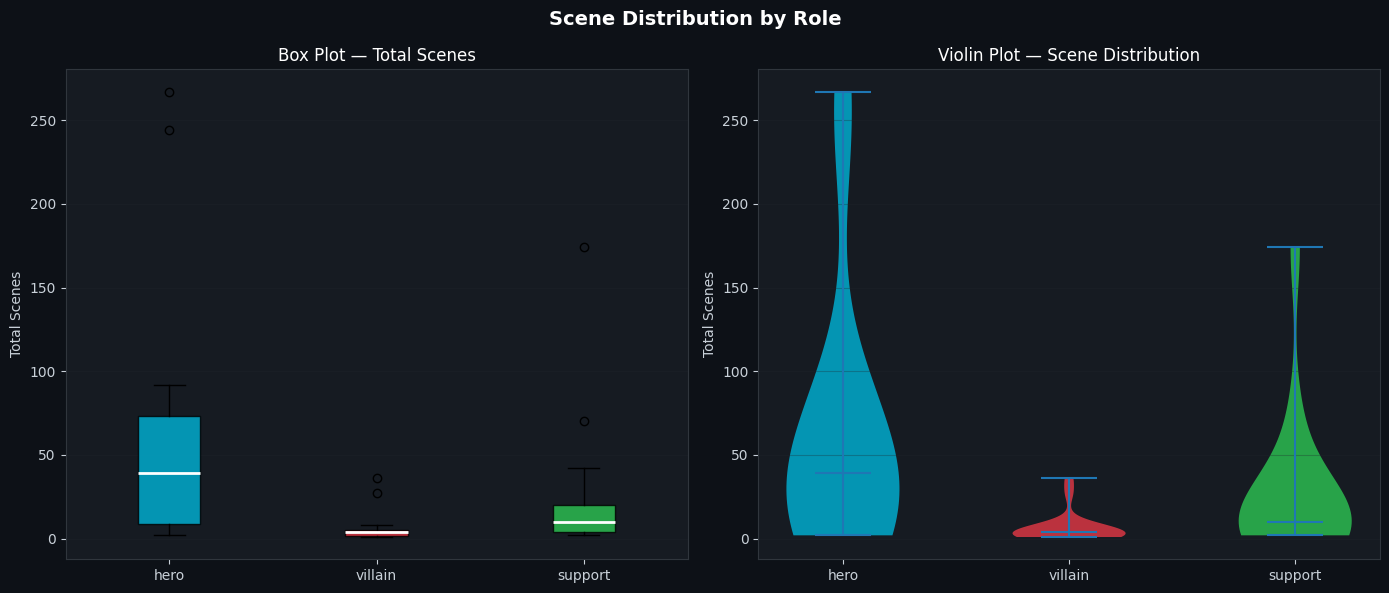

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Scene Distribution by Role', fontsize=14, color='white', fontweight='bold')

roles = ['hero','villain','support']
data_box = [char_features[char_features['char_role']==r]['total_scenes'].values for r in roles]

bp = axes[0].boxplot(data_box, patch_artist=True, labels=roles,
                     medianprops=dict(color='white', linewidth=2))
for patch, role in zip(bp['boxes'], roles):
    patch.set_facecolor(PALETTE[role])
    patch.set_alpha(0.8)
axes[0].set_ylabel('Total Scenes')
axes[0].set_title('Box Plot — Total Scenes', color='white')
axes[0].grid(axis='y', alpha=0.3)

parts = axes[1].violinplot(data_box, positions=[1, 2, 3], showmedians=True)
for i, (pc, role) in enumerate(zip(parts['bodies'], roles)):
    pc.set_facecolor(PALETTE[role])
    pc.set_alpha(0.8)
axes[1].set_xticks([1, 2, 3])
axes[1].set_xticklabels(roles)
axes[1].set_ylabel('Total Scenes')
axes[1].set_title('Violin Plot — Scene Distribution', color='white')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

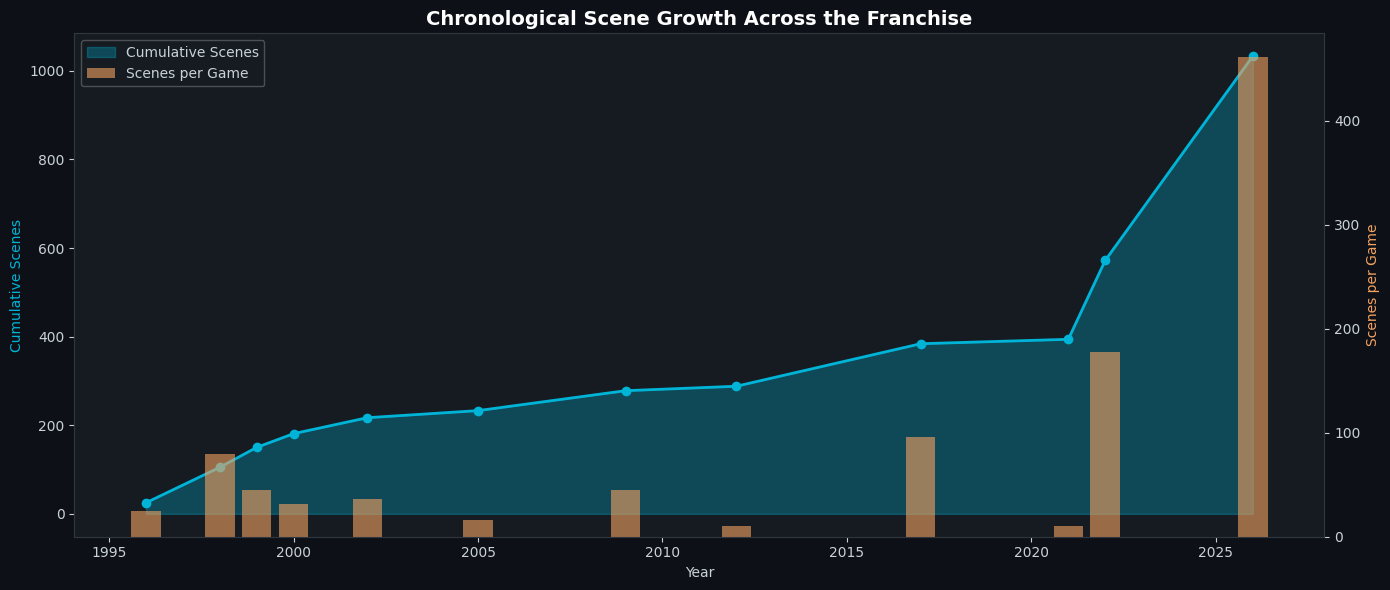

In [ ]:
gf_sorted = game_features.sort_values('year')
gf_sorted['cumulative_scenes'] = gf_sorted['total_scenes'].cumsum()

fig, ax1 = plt.subplots(figsize=(14, 6))
ax2 = ax1.twinx()

ax1.fill_between(gf_sorted['year'], gf_sorted['cumulative_scenes'],
                 alpha=0.3, color='#00b4d8', label='Cumulative Scenes')
ax1.plot(gf_sorted['year'], gf_sorted['cumulative_scenes'],
         color='#00b4d8', linewidth=2, marker='o')
ax2.bar(gf_sorted['year'], gf_sorted['total_scenes'],
        alpha=0.6, color='#f4a261', width=0.8, label='Scenes per Game')

ax1.set_xlabel('Year')
ax1.set_ylabel('Cumulative Scenes', color='#00b4d8')
ax2.set_ylabel('Scenes per Game', color='#f4a261')
ax1.set_title('Chronological Scene Growth Across the Franchise', fontsize=14, color='white', fontweight='bold')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', framealpha=0.3)

plt.tight_layout()
plt.show()

## 6. Plotly Interactive Visualisations

In [ ]:
sun_data = appearances.copy()
fig_sun = px.sunburst(
    sun_data,
    path=['game_title', 'role', 'character_name'],
    color='role',
    color_discrete_map=PALETTE,
    title='🌞 Character Universe — Games → Roles → Characters',
)
fig_sun.update_layout(
    paper_bgcolor='#0d1117', font_color='white',
    title_font_size=16
)
fig_sun.show()

In [ ]:
fig_tree = px.treemap(
    char_features.nlargest(40, 'total_scenes'),
    path=['char_role', 'char_name'],
    values='total_scenes',
    color='char_role',
    color_discrete_map=PALETTE,
    title='🌳 Treemap: Character Screen Time by Role'
)
fig_tree.update_layout(paper_bgcolor='#0d1117', font_color='white')
fig_tree.show()

In [ ]:
game_role = (master.groupby(['game_title','char_role'])['character_id']
             .nunique().reset_index(name='count'))

games_list = game_role['game_title'].unique().tolist()
roles_list = game_role['char_role'].unique().tolist()
nodes = games_list + roles_list
node_idx = {n: i for i, n in enumerate(nodes)}

role_node_colors = {'hero': '#00b4d8', 'villain': '#e63946', 'support': '#2dc653'}
node_colors = ['#6e40c9'] * len(games_list) + [role_node_colors[r] for r in roles_list]

fig_sankey = go.Figure(go.Sankey(
    node=dict(pad=15, thickness=20, line=dict(color='black', width=0.5),
              label=nodes, color=node_colors),
    link=dict(
        source=[node_idx[r['game_title']] for _, r in game_role.iterrows()],
        target=[node_idx[r['char_role']]  for _, r in game_role.iterrows()],
        value=[r['count']                 for _, r in game_role.iterrows()],
        color=[role_node_colors[r['char_role']] for _, r in game_role.iterrows()]
    )
))
fig_sankey.update_layout(
    title_text='🌊 Sankey: Game → Character Role Flow',
    font_size=11, paper_bgcolor='#0d1117', font_color='white', height=700
)
fig_sankey.show()

In [ ]:
fig_3d = px.scatter_3d(
    char_features,
    x='career_span', y='games_count', z='total_scenes',
    color='char_role',
    size='scenes_per_game',
    hover_name='char_name',
    color_discrete_map=PALETTE,
    title='🔮 3D: Career Span × Games × Scene Count'
)
fig_3d.update_layout(paper_bgcolor='#0d1117', font_color='white')
fig_3d.show()

In [ ]:
frames_data = []
gf_chron = game_features.sort_values('chronology_order')
running = {}
for _, grow in gf_chron.iterrows():
    game_chars = master[master['game_id'] == grow['game_id']].groupby('char_name')['scene_id'].count()
    for ch, cnt in game_chars.items():
        running[ch] = running.get(ch, 0) + cnt
    top10 = sorted(running.items(), key=lambda x: x[1], reverse=True)[:10]
    for name, val in top10:
        frames_data.append({'Game': grow['game_title'], 'Character': name, 'Scenes': val,
                            'Role': char_features.set_index('char_name')['char_role'].get(name, 'support')})

frames_df = pd.DataFrame(frames_data)
fig_anim = px.bar(
    frames_df, x='Scenes', y='Character', color='Role',
    animation_frame='Game', orientation='h',
    color_discrete_map=PALETTE,
    title='🎬 Animated: Cumulative Scene Appearances (Top 10 per Chronological Game)'
)
fig_anim.update_layout(
    paper_bgcolor='#0d1117', font_color='white',
    yaxis={'categoryorder': 'total ascending'},
    height=550
)
fig_anim.show()

In [ ]:
char_game_mat = (master.groupby(['char_name','game_title'])['scene_id']
                 .count().unstack(fill_value=0))
top_chars = char_features.nlargest(25, 'total_scenes')['char_name']
mat = char_game_mat.loc[char_game_mat.index.isin(top_chars)]

fig_heat = px.imshow(
    mat, text_auto=True,
    color_continuous_scale='Plasma',
    aspect='auto',
    title='🔥 Character × Game Scene Interaction Heatmap (Top 25 Characters)'
)
fig_heat.update_layout(paper_bgcolor='#0d1117', font_color='white', height=700)
fig_heat.show()

In [ ]:
radar_data = role_dist.copy()
fig_radar = go.Figure()
categories = [c for c in ['hero', 'villain', 'support'] if c in radar_data.columns]

for _, row in radar_data.iterrows():
    vals = [row.get(c, 0) for c in categories]
    vals += vals[:1]  # close polygon
    fig_radar.add_trace(go.Scatterpolar(
        r=vals, theta=categories + [categories[0]],
        fill='toself', name=row['game_title'].replace('Resident Evil', 'RE'),
        opacity=0.65
    ))

fig_radar.update_layout(
    polar=dict(radialaxis=dict(visible=True, gridcolor='#30363d'),
               bgcolor='#161b22'),
    showlegend=True, paper_bgcolor='#0d1117', font_color='white',
    title='🕸 Radar: Role Composition per Game', height=600
)
fig_radar.show()

In [ ]:
fig_bubble = px.scatter(
    game_features, x='year', y='total_scenes',
    size='unique_characters', color='type',
    hover_name='game_title',
    text='game_title',
    size_max=60,
    color_discrete_map={'mainline': '#00b4d8', 'spinoff': '#f4a261'},
    title='🫧 Bubble: Year × Scenes × Unique Characters per Game'
)
fig_bubble.update_traces(textposition='top center', textfont_size=9)
fig_bubble.update_layout(paper_bgcolor='#0d1117', font_color='white')
fig_bubble.show()

## 7. Machine Learning

In [ ]:
le = LabelEncoder()
ml_df = char_features.copy()
ml_df['role_encoded'] = le.fit_transform(ml_df['char_role'])

FEATURE_COLS = ['total_scenes','unique_scenes','games_count','avg_chron',
                'career_span','scenes_per_game','multi_game_flag']
TARGET = 'role_encoded'

X = ml_df[FEATURE_COLS]
y = ml_df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y)

print(f'Train: {X_train.shape}  Test: {X_test.shape}')
print('Classes:', le.classes_)

Train: (38, 7)  Test: (13, 7)
Classes: ['hero' 'support' 'villain']


In [ ]:
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

models = {
    'Random Forest':         RandomForestClassifier(n_estimators=200, random_state=42),
    'Gradient Boosting':     GradientBoostingClassifier(n_estimators=150, random_state=42),
    'Logistic Regression':   LogisticRegression(max_iter=1000, random_state=42),
}

results = {}
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    Xt = X_train_s if name == 'Logistic Regression' else X_train
    Xe = X_test_s  if name == 'Logistic Regression' else X_test
    cv_scores = cross_val_score(model, Xt, y_train, cv=skf, scoring='accuracy')
    model.fit(Xt, y_train)
    preds = model.predict(Xe)
    acc   = accuracy_score(y_test, preds)
    results[name] = {'model': model, 'preds': preds, 'acc': acc,
                     'cv_mean': cv_scores.mean(), 'cv_std': cv_scores.std()}
    print(f'  {name:25s} → CV: {cv_scores.mean():.3f}±{cv_scores.std():.3f}  Test Acc: {acc:.3f}')

best_name = max(results, key=lambda k: results[k]['acc'])
best = results[best_name]
print(f'\n Best model: {best_name}  (Test Acc = {best["acc"]:.3f})')

  Random Forest             → CV: 0.514±0.192  Test Acc: 0.385
  Gradient Boosting         → CV: 0.539±0.226  Test Acc: 0.462
  Logistic Regression       → CV: 0.443±0.115  Test Acc: 0.385

 Best model: Gradient Boosting  (Test Acc = 0.462)


In [ ]:
print(f'\n=== Classification Report: {best_name} ===')
print(classification_report(y_test, best['preds'], target_names=le.classes_))


=== Classification Report: Gradient Boosting ===
              precision    recall  f1-score   support

        hero       0.33      0.50      0.40         4
     support       0.00      0.00      0.00         4
     villain       0.57      0.80      0.67         5

    accuracy                           0.46        13
   macro avg       0.30      0.43      0.36        13
weighted avg       0.32      0.46      0.38        13



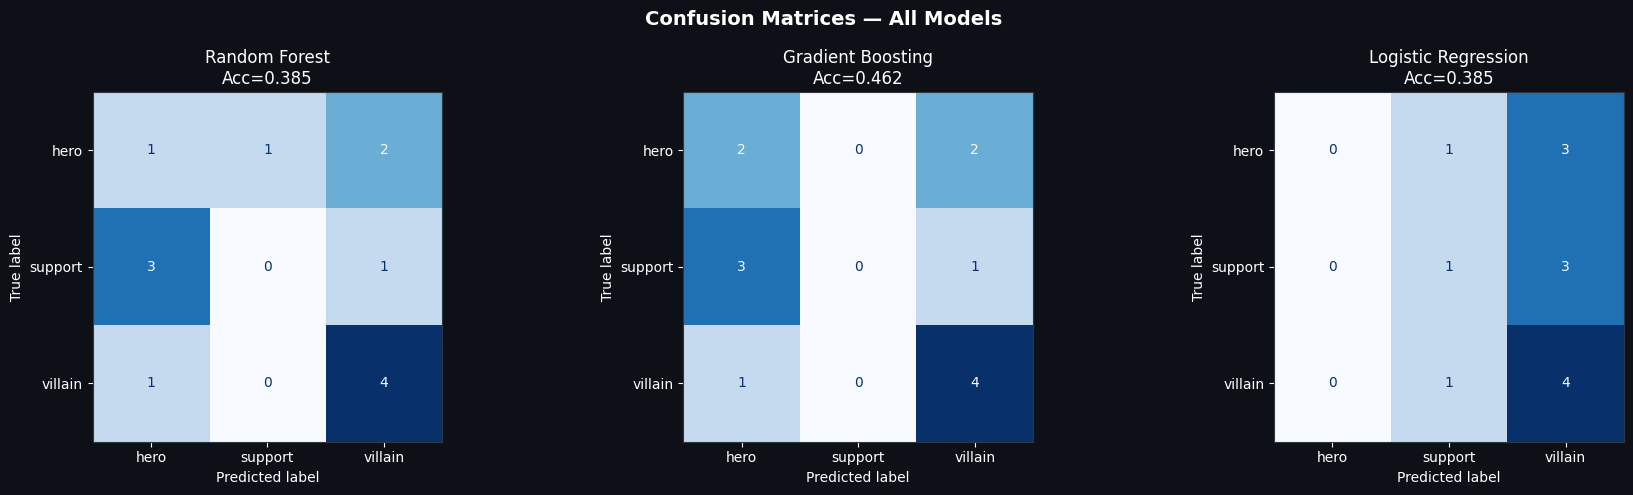

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Confusion Matrices — All Models', fontsize=14, color='white', fontweight='bold')

for ax, (mname, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res['preds'])
    disp = ConfusionMatrixDisplay(cm, display_labels=le.classes_)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{mname}\nAcc={res["acc"]:.3f}', color='white')
    ax.tick_params(colors='white')
    ax.xaxis.label.set_color('white')
    ax.yaxis.label.set_color('white')

plt.tight_layout()
plt.show()

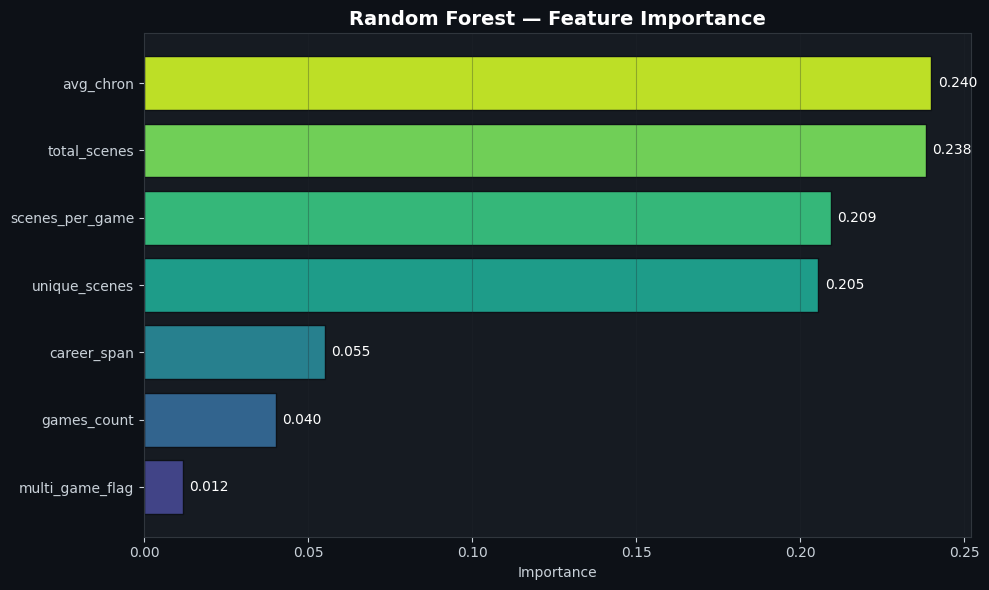

In [ ]:
rf_model = results['Random Forest']['model']
fi = pd.Series(rf_model.feature_importances_, index=FEATURE_COLS).sort_values()

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(fi.index, fi.values,
               color=plt.cm.viridis(np.linspace(0.2, 0.9, len(fi))),
               edgecolor='#0d1117')
for bar, val in zip(bars, fi.values):
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', color='white', fontsize=10)
ax.set_xlabel('Importance')
ax.set_title('Random Forest — Feature Importance', fontsize=14, color='white', fontweight='bold')
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

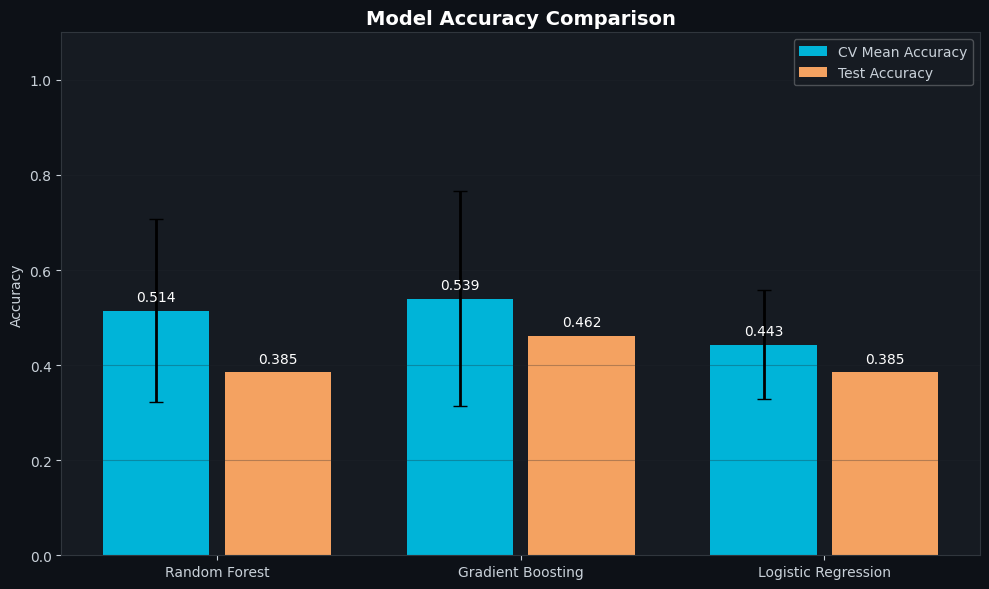

In [ ]:
model_names = list(results.keys())
cv_means = [results[m]['cv_mean'] for m in model_names]
cv_stds  = [results[m]['cv_std']  for m in model_names]
test_accs= [results[m]['acc']     for m in model_names]

x = np.arange(len(model_names))
fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(x - 0.2, cv_means,  0.35, label='CV Mean Accuracy',   color='#00b4d8',
       yerr=cv_stds, capsize=5, error_kw={'color': 'white', 'linewidth': 2})
ax.bar(x + 0.2, test_accs, 0.35, label='Test Accuracy',      color='#f4a261')

for xi, (cv, te) in enumerate(zip(cv_means, test_accs)):
    ax.text(xi - 0.2, cv + 0.02, f'{cv:.3f}', ha='center', color='white', fontsize=10)
    ax.text(xi + 0.2, te + 0.02, f'{te:.3f}', ha='center', color='white', fontsize=10)

ax.set_xticks(x)
ax.set_xticklabels(model_names)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Accuracy')
ax.set_title('Model Accuracy Comparison', fontsize=14, color='white', fontweight='bold')
ax.legend(framealpha=0.3)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

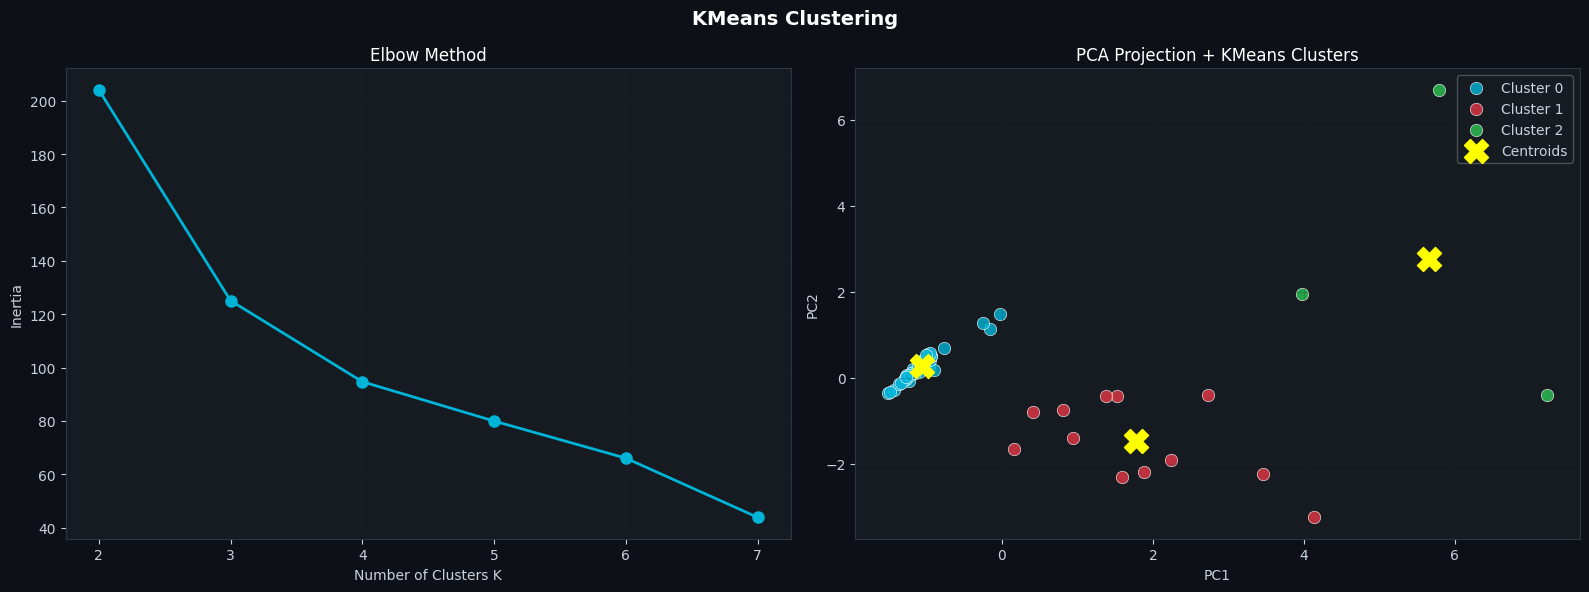

In [31]:

Xs = StandardScaler().fit_transform(X)
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(Xs)

inertias = []
K_range = range(2, 8)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init='auto')
    km.fit(Xs)
    inertias.append(km.inertia_)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('KMeans Clustering', fontsize=14, color='white', fontweight='bold')

axes[0].plot(list(K_range), inertias, 'o-', color='#00b4d8', linewidth=2, markersize=8)
axes[0].set_xlabel('Number of Clusters K')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method', color='white')
axes[0].grid(alpha=0.3)

km3 = KMeans(n_clusters=3, random_state=42, n_init='auto')
clusters = km3.fit_predict(Xs)
scatter_colors = ['#00b4d8','#e63946','#2dc653']
for i in range(3):
    mask = clusters == i
    axes[1].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    color=scatter_colors[i], label=f'Cluster {i}',
                    s=80, alpha=0.8, edgecolors='white', linewidth=0.5)

axes[1].scatter(pca.transform(km3.cluster_centers_)[:,0],
                pca.transform(km3.cluster_centers_)[:,1],
                marker='X', s=300, color='yellow', zorder=10, label='Centroids')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
axes[1].set_title('PCA Projection + KMeans Clusters', color='white')
axes[1].legend(framealpha=0.3)
axes[1].grid(alpha=0.2)

plt.tight_layout()
plt.show()

In [ ]:
pca_df = pd.DataFrame({'PC1': X_pca[:,0], 'PC2': X_pca[:,1],
                       'Cluster': clusters.astype(str),
                       'Character': ml_df['char_name'],
                       'Role': ml_df['char_role'],
                       'Total Scenes': ml_df['total_scenes']})

fig_pca = px.scatter(pca_df, x='PC1', y='PC2', color='Cluster',
                     symbol='Role', hover_name='Character',
                     size='Total Scenes', size_max=40,
                     title='🔬 Interactive PCA — Character Clustering')
fig_pca.update_layout(paper_bgcolor='#0d1117', font_color='white')
fig_pca.show()

## 8. Summary Statistics Dashboard

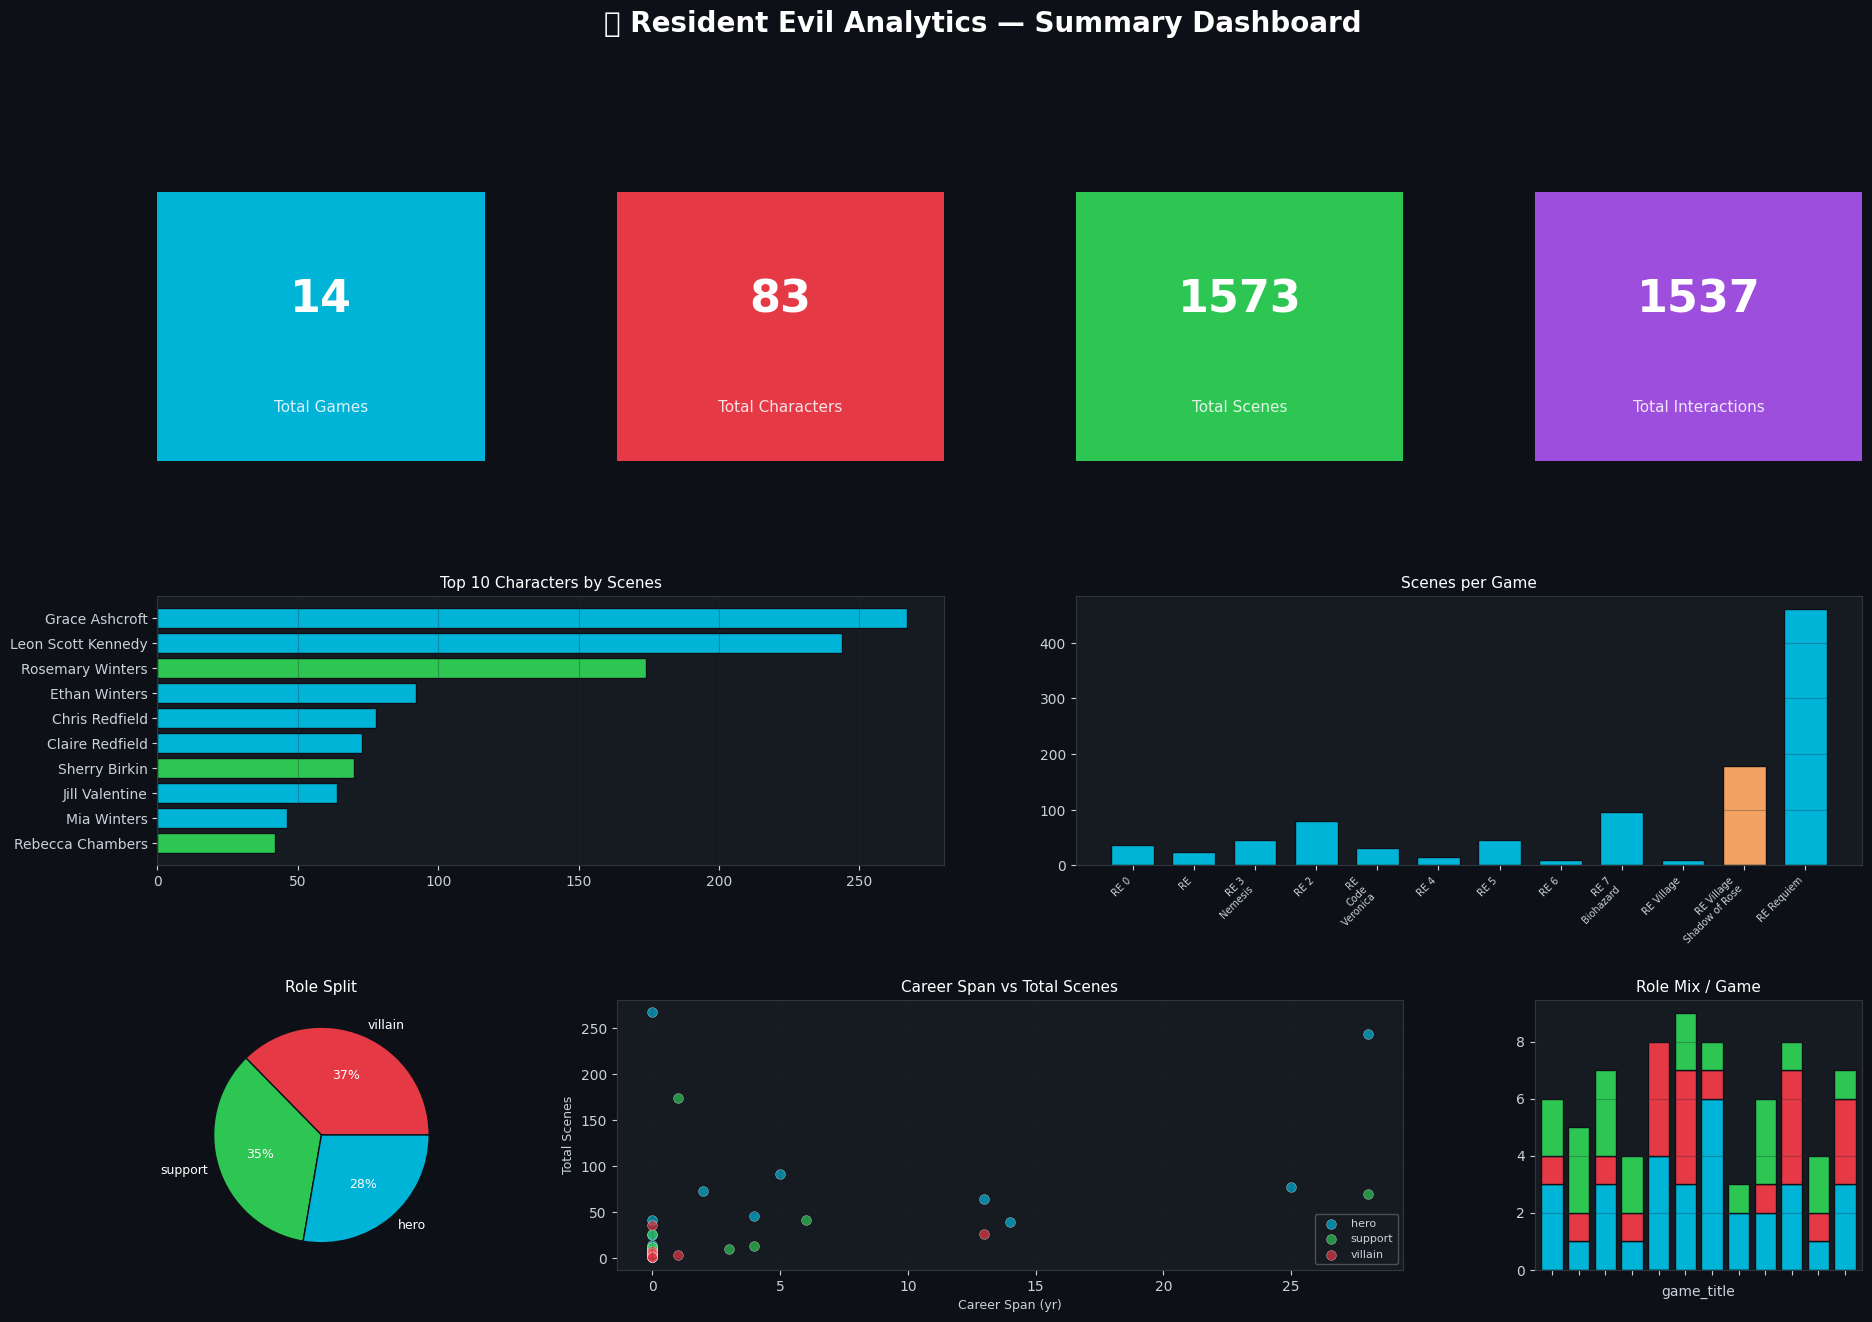

In [ ]:
fig = plt.figure(figsize=(22, 14))
fig.patch.set_facecolor('#0d1117')
fig.suptitle('🎮 Resident Evil Analytics — Summary Dashboard', fontsize=20,
             color='white', fontweight='bold', y=1.01)

gs = gridspec.GridSpec(3, 4, hspace=0.5, wspace=0.4)

kpis = [
    ('Total Games',       str(len(games))),
    ('Total Characters',  str(len(chars))),
    ('Total Scenes',      str(scenes['scene_id'].nunique())),
    ('Total Interactions',str(len(interactions))),
]
kpi_colors = ['#00b4d8','#e63946','#2dc653','#9d4edd']
for i, ((label, val), col) in enumerate(zip(kpis, kpi_colors)):
    ax = fig.add_subplot(gs[0, i])
    ax.set_facecolor(col)
    ax.text(0.5, 0.6, val, ha='center', va='center',
            fontsize=32, fontweight='bold', color='white', transform=ax.transAxes)
    ax.text(0.5, 0.2, label, ha='center', va='center',
            fontsize=11, color='white', alpha=0.85, transform=ax.transAxes)
    ax.set_xticks([]); ax.set_yticks([])
    for spine in ax.spines.values(): spine.set_visible(False)

ax_bar = fig.add_subplot(gs[1, :2])
top10 = char_features.nlargest(10, 'total_scenes')
ax_bar.barh(top10['char_name'], top10['total_scenes'],
            color=[PALETTE[r] for r in top10['char_role']], edgecolor='#0d1117')
ax_bar.set_title('Top 10 Characters by Scenes', color='white', fontsize=11)
ax_bar.invert_yaxis(); ax_bar.grid(axis='x', alpha=0.3)

ax_gbar = fig.add_subplot(gs[1, 2:])
gf_s = game_features.sort_values('chronology_order')
c_map = {'mainline': '#00b4d8', 'spinoff': '#f4a261'}
ax_gbar.bar([t.replace('Resident Evil','RE').replace(': ','\n').replace(' –','\n') for t in gf_s['game_title']],
            gf_s['total_scenes'],
            color=[c_map[t] for t in gf_s['type']], edgecolor='#0d1117', width=0.7)
ax_gbar.set_xticklabels(ax_gbar.get_xticklabels(), rotation=45, ha='right', fontsize=7)
ax_gbar.set_title('Scenes per Game', color='white', fontsize=11)
ax_gbar.grid(axis='y', alpha=0.3)

ax_pie = fig.add_subplot(gs[2, 0])
rc = chars['role'].value_counts()
ax_pie.pie(rc, labels=rc.index, colors=[PALETTE[r] for r in rc.index],
           autopct='%1.0f%%', textprops={'color':'white', 'fontsize': 9},
           wedgeprops={'edgecolor':'#0d1117'})
ax_pie.set_title('Role Split', color='white', fontsize=11)

ax_sc = fig.add_subplot(gs[2, 1:3])
for role, grp in char_features.groupby('char_role'):
    ax_sc.scatter(grp['career_span'], grp['total_scenes'],
                  color=PALETTE[role], label=role, alpha=0.7, s=50, edgecolors='white', lw=0.3)
ax_sc.set_xlabel('Career Span (yr)', fontsize=9)
ax_sc.set_ylabel('Total Scenes', fontsize=9)
ax_sc.set_title('Career Span vs Total Scenes', color='white', fontsize=11)
ax_sc.legend(fontsize=8, framealpha=0.3); ax_sc.grid(alpha=0.2)

ax_stack = fig.add_subplot(gs[2, 3])
rd = role_dist.set_index('game_title')[[c for c in ['hero','villain','support'] if c in role_dist.columns]]
rd.plot(kind='bar', stacked=True, ax=ax_stack, width=0.8,
        color=[PALETTE.get(c,'#888') for c in rd.columns], edgecolor='#0d1117', legend=False)
ax_stack.set_xticklabels([], fontsize=0)
ax_stack.set_title('Role Mix / Game', color='white', fontsize=11)
ax_stack.grid(axis='y', alpha=0.3)

plt.show()